In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from transformers import pipeline
from sklearn.metrics import accuracy_score
from transformers import pipeline
from wordcloud import WordCloud

C:\Users\gmgma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the data
df = pd.read_csv('Combined Data.csv')
df = df.drop(columns=['Unnamed: 0'], axis=1)
df.fillna('',inplace=True)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


# Exploratory Data Analysis

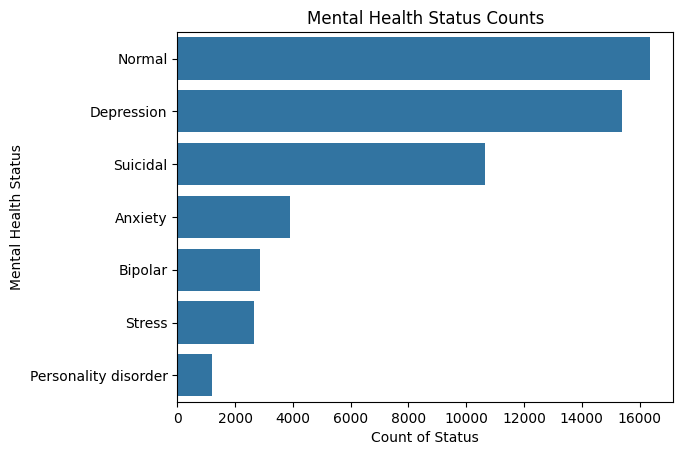

In [3]:
# plotting status counts
sns.countplot(df['status'], order = df['status'].value_counts().index)
plt.xlabel('Count of Status')
plt.ylabel('Mental Health Status')
plt.title('Mental Health Status Counts')
plt.show()

From the count plot we can see a majority of cases are Normal, Depression, and Suicidal. 

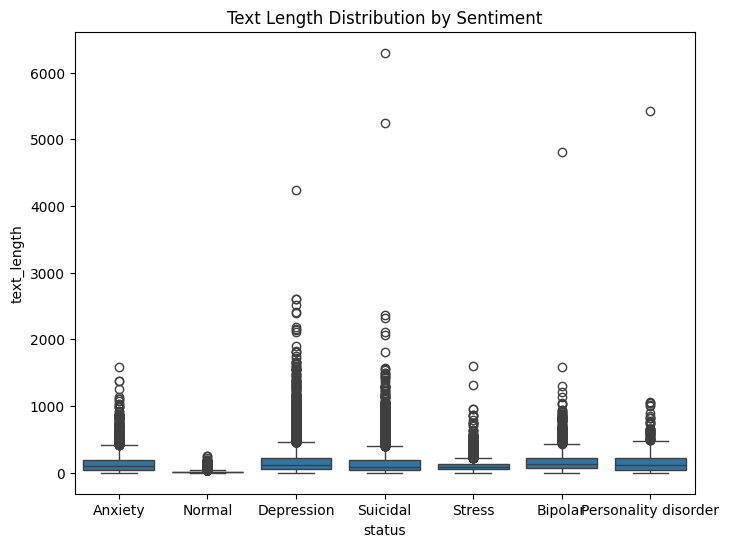

In [77]:
# Fill NaN values in 'statement' column with empty string
df['statement'] = df['statement'].fillna('')

df['text_length'] = df['statement'].apply(lambda x: len(x.split()))

# Plot distribution of statement length for each status
plt.figure(figsize=(8, 6))
sns.boxplot(x='status', y='text_length', data=df)
plt.title('Text Length Distribution by Sentiment')
plt.show()

From the above chart we can see there are some outlier statements with very long text lengths. A majority of statements are below 3,000. We can also see the Normal class has the shortest text lengths overall.

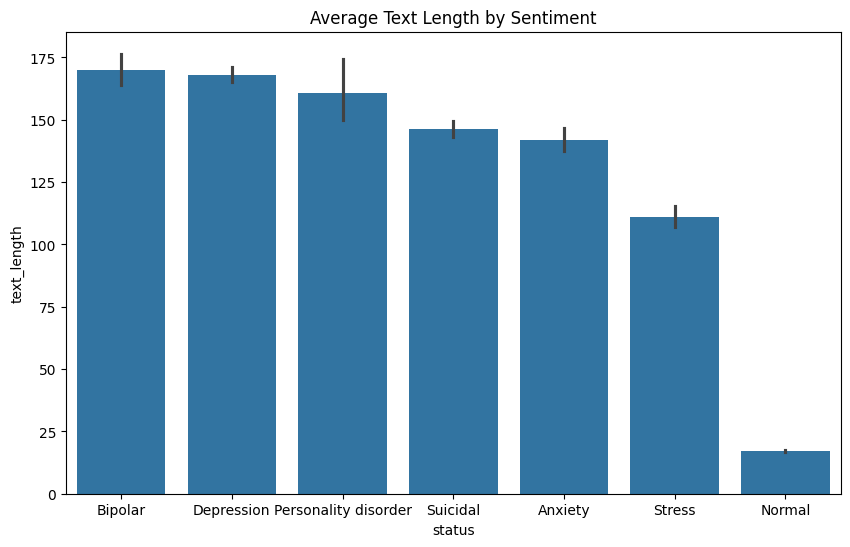

In [78]:
# Average length by status bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='status', y='text_length', data=df, order= df.groupby('status')['text_length'].mean().sort_values(ascending=False).index)
plt.title('Average Text Length by Sentiment')
plt.show()

From the above chart we can see the statements classified as Normal have the least average text length, while statement with mental health problems tend to have longer statements on average.

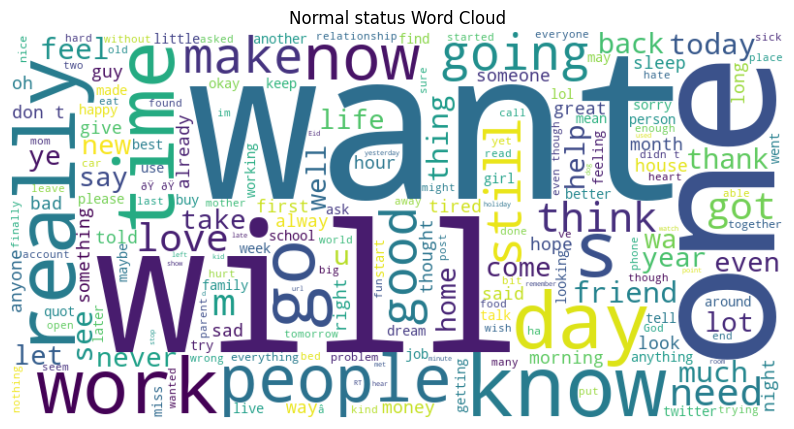

In [79]:
# Generate word cloud for a status classes
normal_text = ' '.join(df[df['status'] == 'Normal']['statement'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(normal_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Normal status Word Cloud')
plt.axis('off')
plt.show()

Nothing really stands out to me as an indicator of the Normal class in the above word cloud visualization. 

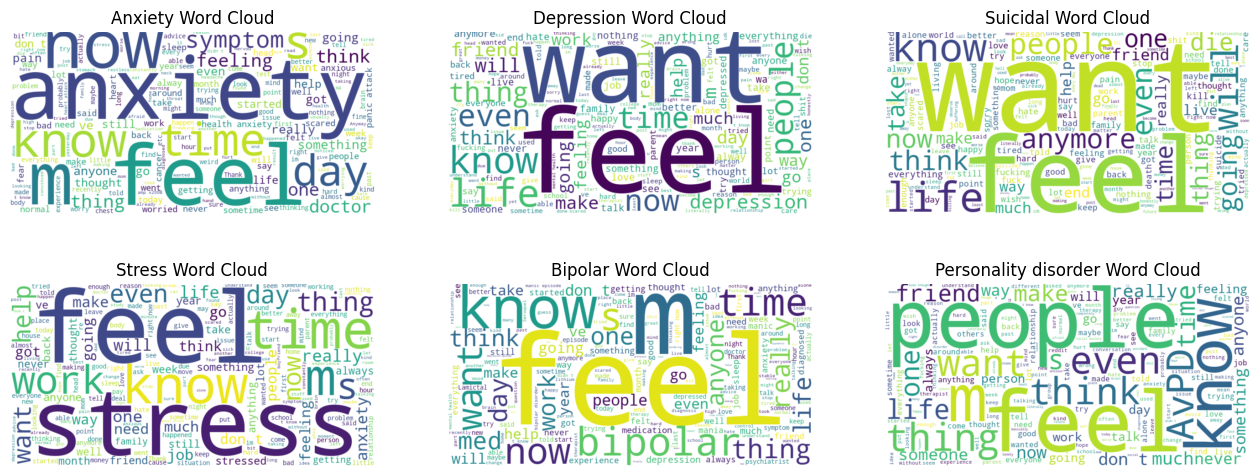

In [80]:
# Generate word cloud for status classes
fig, ax = plt.subplots(2, 3, figsize=(16, 6))

# Get unique statuses excluding 'Normal'
statuses = df[df['status'] != 'Normal']['status'].unique()

for i, status in enumerate(statuses):
    # Combine all statements for the current status
    text = ' '.join(df[df['status'] == status]['statement'])
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    # Display word cloud
    ax[i//3, i%3].imshow(wordcloud, interpolation='bilinear')
    ax[i//3, i%3].set_title(f'{status} Word Cloud')
    ax[i//3, i%3].axis('off')
plt.show()

The above word clouds don't give me too much insight. The main thing I notice from all the classes with mental health issue is "feel", "know", and the words of their classification showing up in the clouds. 

# Modeling

All modeling was done in the previous versions of this Kaggle notebook:

https://www.kaggle.com/code/grantgonnerman/mental-health-sentiment-analysis-eda-modeling